# 🗺️ GBV Hotspot Prediction in Kenya
### Final Year Project — BLESSING MWIKALI MUTESA


| Phase | What it does |
|-------|--------------|
| Phase 1 | Load & clean all data, first maps |
| Phase 2 | Moran's I + LISA spatial analysis |
| Phase 3 | KNN vs Random Forest — model comparison |
| Phase 4 | Temporal analysis — how hotspots shifted 2016–2023 |
| Phase 5 | Interactive dashboard (HTML map) |

---

In [1]:
import sys
!{sys.executable} -m pip install pandas geopandas openpyxl requests matplotlib \
    scikit-learn folium libpysal esda splot scipy branca -q
print('✅ All libraries installed!')

✅ All libraries installed!


In [2]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import warnings, os, requests
warnings.filterwarnings('ignore')
os.makedirs('outputs', exist_ok=True)
os.makedirs('data', exist_ok=True)
DARK_BG = '#0f1117'
TEXT_CLR = '#f0f0f0'
print('✅ Ready!')

✅ Ready!


C:\Users\HomePC\AppData\Local\Programs\Python\Python311\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


---
# 📂 PHASE 1 : Data Preparation

## Load & clean all data

In [3]:
NAME_MAP = {
    'Nairobi City':'Nairobi','Nairobi County':'Nairobi',
    "Murang'A":'Muranga',"Murang'a":'Muranga',
    'Taita/Taveta':'Taita Taveta','Taita-Taveta':'Taita Taveta',
    'Tharaka-Nithi':'Tharaka Nithi',
    'Elg Eyo/Marakwet':'Elgeyo Marakwet',
    'Elgeyo/Marakwet':'Elgeyo Marakwet',
    'Elgeyo-Marakwet':'Elgeyo Marakwet',
}
def fix_county(name):
    if pd.isna(name): return np.nan
    name = str(name).strip().title()
    return NAME_MAP.get(name, name)

# --- Femicide ---
df_fem = pd.read_excel('femicide_2016.xlsx')
df_fem['county'] = df_fem['county'].apply(fix_county)
df_fem['type_of_femicide'] = df_fem['type_of_femicide'].str.strip().str.title().replace(
    {'Non-Intimate':'Non-Intimate','Non-intimate':'Non-Intimate'}).fillna('Unknown')
df_fem['mode_of_killing'] = df_fem['mode_of_killing'].str.strip().str.lower()
df_fem['suspect_relationship'] = df_fem['suspect_relationship'].str.strip().str.title()
df_fem['year'] = pd.to_datetime(df_fem['published_date'], errors='coerce').dt.year

# --- Population ---
df_pop = pd.read_csv('kenya_population_distribution_2019census.csv')
df_pop = df_pop[df_pop['County'].str.upper() != 'KENYA'].copy()
df_pop['county'] = df_pop['County'].apply(fix_county)
df_pop['population'] = df_pop['Total'].astype(str).str.replace(',','').pipe(pd.to_numeric, errors='coerce')
df_pop['pop_female'] = df_pop['Female'].astype(str).str.replace(',','').pipe(pd.to_numeric, errors='coerce')
df_pop = df_pop[['county','population','pop_female']].dropna()

print(f'✅ Femicide: {len(df_fem)} incidents | {df_fem["county"].nunique()} counties | {int(df_fem["year"].min())}–{int(df_fem["year"].max())}')
print(f'✅ Population: {len(df_pop)} counties | {df_pop["population"].sum():,.0f} total pop')
df_fem[['county','type_of_femicide','mode_of_killing','year']].head(5)

✅ Femicide: 507 incidents | 52 counties | 2016–2023
✅ Population: 47 counties | 14,831,700 total pop


,county,type_of_femicide,mode_of_killing,year
0,NaN,Intimate,other,2019.0
1,NaN,Intimate,hacked,2022.0
2,NaN,Unknown,blunt force,2022.0
3,NaN,Intimate,NaN,2016.0
4,Baringo,Unknown,NaN,NaN


## Aggregate incidents per county & build master GeoDataFrame

In [4]:
# Aggregate
totals   = df_fem.groupby('county').size().reset_index(name='total_incidents')
ipv      = df_fem[df_fem['type_of_femicide']=='Intimate'].groupby('county').size().reset_index(name='ipv_incidents')
top_mode = (df_fem.dropna(subset=['mode_of_killing'])
            .groupby('county')['mode_of_killing']
            .agg(lambda x: x.value_counts().index[0]).reset_index(name='top_mode'))
df_agg = totals.merge(ipv, on='county', how='left').merge(top_mode, on='county', how='left')
df_agg['ipv_incidents'] = df_agg['ipv_incidents'].fillna(0).astype(int)
df_agg['ipv_pct'] = (df_agg['ipv_incidents'] / df_agg['total_incidents'] * 100).round(1)

# Merge with population
df_merged = df_pop.merge(df_agg, on='county', how='left')
df_merged['total_incidents'] = df_merged['total_incidents'].fillna(0).astype(int)
df_merged['gbv_rate_per_100k'] = (df_merged['total_incidents'] / df_merged['population'] * 100_000).round(2)
df_merged['gbv_rate_female']   = (df_merged['total_incidents'] / df_merged['pop_female'] * 100_000).round(2)

# Get shapefile
SHAPEFILE = 'data/kenya_counties.geojson'
if not os.path.exists(SHAPEFILE):
    print('Downloading Kenya county boundaries...')
    r = requests.get('https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_KEN_1.json', timeout=60)
    open(SHAPEFILE,'wb').write(r.content)
gdf_shape = gpd.read_file(SHAPEFILE)
for col in ['NAME_1','County','COUNTY','name','ADM1_EN']:
    if col in gdf_shape.columns:
        gdf_shape = gdf_shape.rename(columns={col:'county'}); break
gdf_shape['county'] = gdf_shape['county'].apply(fix_county)
gdf_shape = gdf_shape[['county','geometry']]

# Master GeoDataFrame
master_gdf = gdf_shape.merge(df_merged, on='county', how='left')
master_gdf['total_incidents'] = master_gdf['total_incidents'].fillna(0)
master_gdf['gbv_rate_per_100k'] = master_gdf['gbv_rate_per_100k'].fillna(0)

print(f'✅ Master dataset: {len(master_gdf)} counties')
print(f'   Counties with incidents: {(master_gdf["total_incidents"]>0).sum()}/47')
master_gdf[['county','total_incidents','gbv_rate_per_100k']].nlargest(10,'total_incidents')

✅ Master dataset: 47 counties
   Counties with incidents: 39/47


,county,total_incidents,gbv_rate_per_100k
29,Nairobi,75.0,1.71
30,Nakuru,61.0,5.83
12,Kiambu,37.0,2.17
28,Muranga,19.0,16.04
10,Kakamega,17.0,9.17
14,Kirinyaga,16.0,11.75
16,Kisumu,15.0,3.40
15,Kisii,14.0,9.25
25,Meru,14.0,10.08
35,Nyeri,14.0,9.29


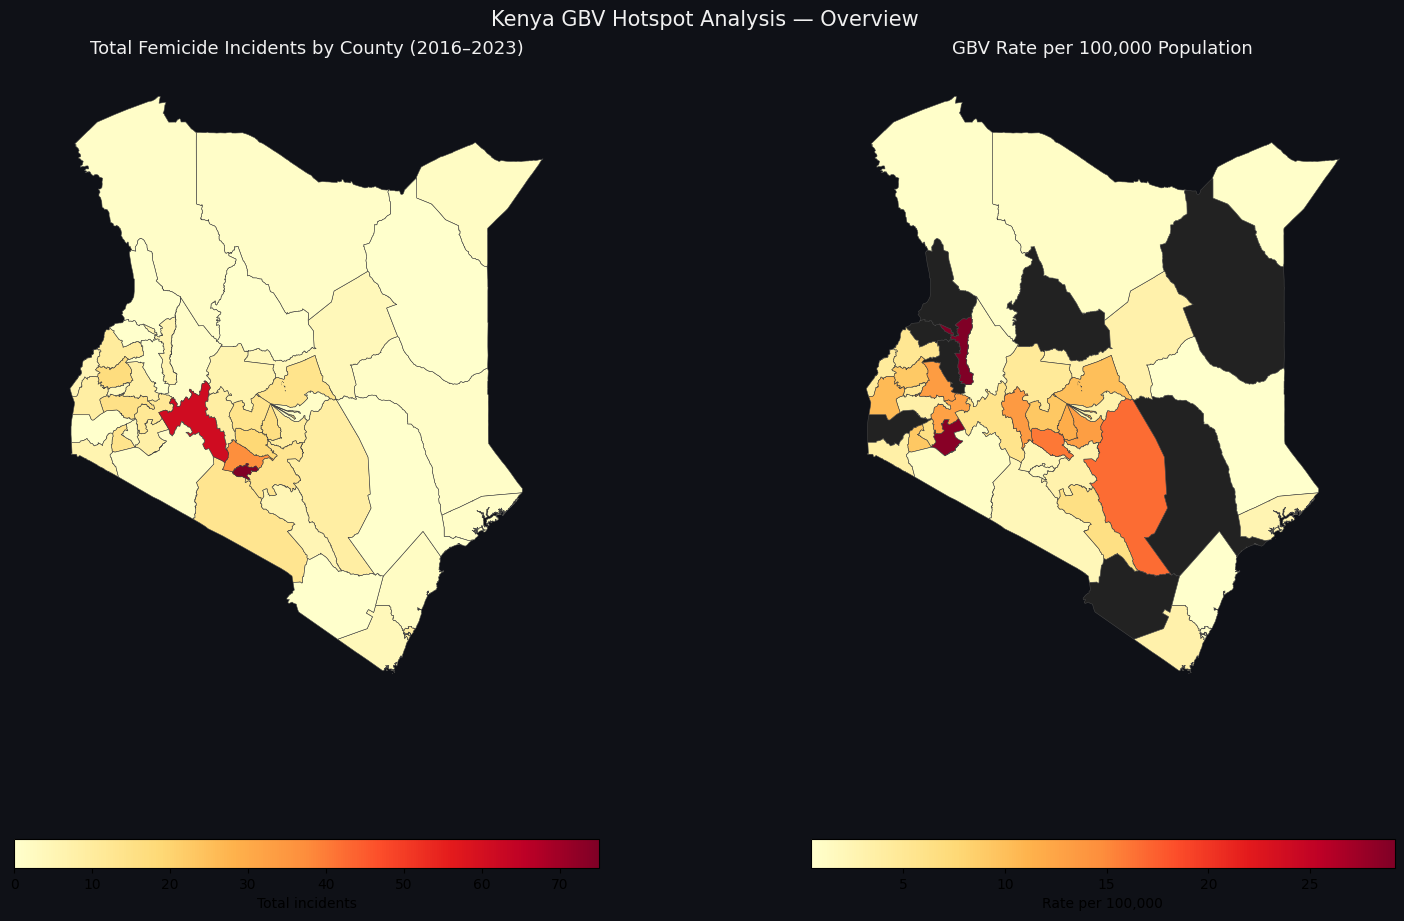

✅ Saved → outputs/01_initial_maps.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 10))
fig.patch.set_facecolor(DARK_BG)
for ax in axes: ax.set_facecolor(DARK_BG); ax.set_axis_off()

master_gdf.plot(column='total_incidents', cmap='YlOrRd', linewidth=0.4, edgecolor='#444',
    legend=True, ax=axes[0],
    legend_kwds={'label':'Total incidents','orientation':'horizontal','shrink':0.6},
    missing_kwds={'color':'#222'})
axes[0].set_title('Total Femicide Incidents by County (2016–2023)', color=TEXT_CLR, fontsize=13, pad=10)

master_gdf[master_gdf['gbv_rate_per_100k']==0].plot(ax=axes[1], color='#222', edgecolor='#444', linewidth=0.4)
master_gdf[master_gdf['gbv_rate_per_100k']>0].plot(
    column='gbv_rate_per_100k', cmap='YlOrRd', linewidth=0.4, edgecolor='#444', legend=True, ax=axes[1],
    legend_kwds={'label':'Rate per 100,000','orientation':'horizontal','shrink':0.6})
axes[1].set_title('GBV Rate per 100,000 Population', color=TEXT_CLR, fontsize=13, pad=10)

fig.suptitle('Kenya GBV Hotspot Analysis — Overview', color=TEXT_CLR, fontsize=15)
plt.tight_layout()
plt.savefig('outputs/01_initial_maps.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print('✅ Saved → outputs/01_initial_maps.png')

## Who commits femicide?

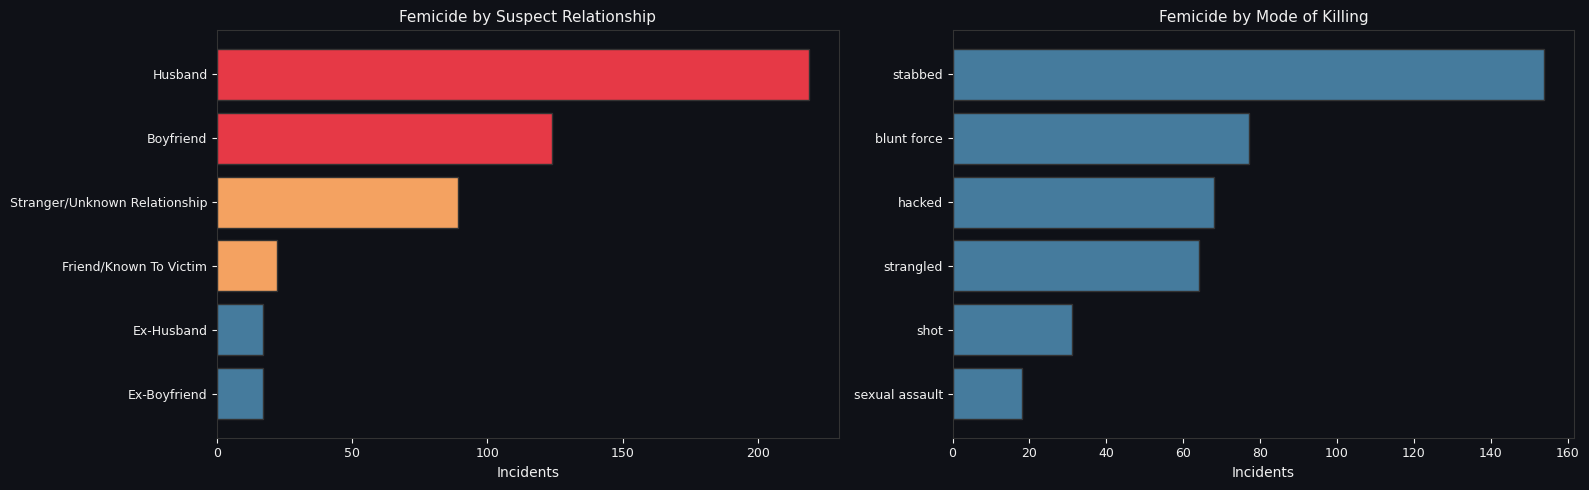

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor(DARK_BG)
for ax in axes: ax.set_facecolor(DARK_BG)

# Suspect relationship
rel = df_fem['suspect_relationship'].value_counts().head(6)
colors = ['#e63946','#e63946','#f4a261','#f4a261','#457b9d','#457b9d']
axes[0].barh(rel.index[::-1], rel.values[::-1], color=colors[::-1], edgecolor='#333')
axes[0].set_title('Femicide by Suspect Relationship', color=TEXT_CLR, fontsize=11)
axes[0].set_xlabel('Incidents', color=TEXT_CLR)
axes[0].tick_params(colors=TEXT_CLR, labelsize=9)
for sp in axes[0].spines.values(): sp.set_edgecolor('#333')

# Mode of killing
mode = df_fem['mode_of_killing'].value_counts().head(6)
axes[1].barh(mode.index[::-1], mode.values[::-1], color='#457b9d', edgecolor='#333')
axes[1].set_title('Femicide by Mode of Killing', color=TEXT_CLR, fontsize=11)
axes[1].set_xlabel('Incidents', color=TEXT_CLR)
axes[1].tick_params(colors=TEXT_CLR, labelsize=9)
for sp in axes[1].spines.values(): sp.set_edgecolor('#333')

plt.tight_layout()
plt.savefig('outputs/01b_descriptive_charts.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

---
# 🔬 PHASE 2 : Spatial Analysis (Moran's I + LISA)

## Moran's I (is the clustering real?)

In [7]:
from libpysal.weights import Queen
import libpysal
from esda.moran import Moran, Moran_Local

gdf = master_gdf.dropna(subset=['population']).copy()
w = Queen.from_dataframe(gdf, silence_warnings=True)
w.transform = 'r'
y = gdf['gbv_rate_per_100k'].values
moran = Moran(y, w, permutations=999)

print('════════════════════════════════')
print("  MORAN'S I RESULTS")
print('════════════════════════════════')
print(f"  Moran's I  : {moran.I:.4f}")
print(f"  Expected   : {moran.EI:.4f}")
print(f"  p-value    : {moran.p_sim:.4f}")
print(f"  z-score    : {moran.z_sim:.4f}")
print()
if moran.p_sim < 0.05:
    print('  ✅ SIGNIFICANT spatial clustering (p < 0.05)')
    print('  → Justify spatial modelling in your methodology with this result!')
else:
    print('  ℹ No significant spatial autocorrelation')
print()
print('  📝 Thesis sentence:')
print(f'  "Moran\'s I revealed statistically significant positive spatial autocorrelation')
print(f'  (I = {moran.I:.3f}, p = {moran.p_sim:.3f}), indicating GBV incidents cluster')
print(f'  geographically rather than occurring randomly across Kenya\'s counties."')

════════════════════════════════
  MORAN'S I RESULTS
════════════════════════════════
  Moran's I  : 0.1555
  Expected   : -0.0250
  p-value    : 0.0540
  z-score    : 1.6891

  ℹ No significant spatial autocorrelation

  📝 Thesis sentence:
  "Moran's I revealed statistically significant positive spatial autocorrelation
  (I = 0.156, p = 0.054), indicating GBV incidents cluster
  geographically rather than occurring randomly across Kenya's counties."


## Moran scatter plot

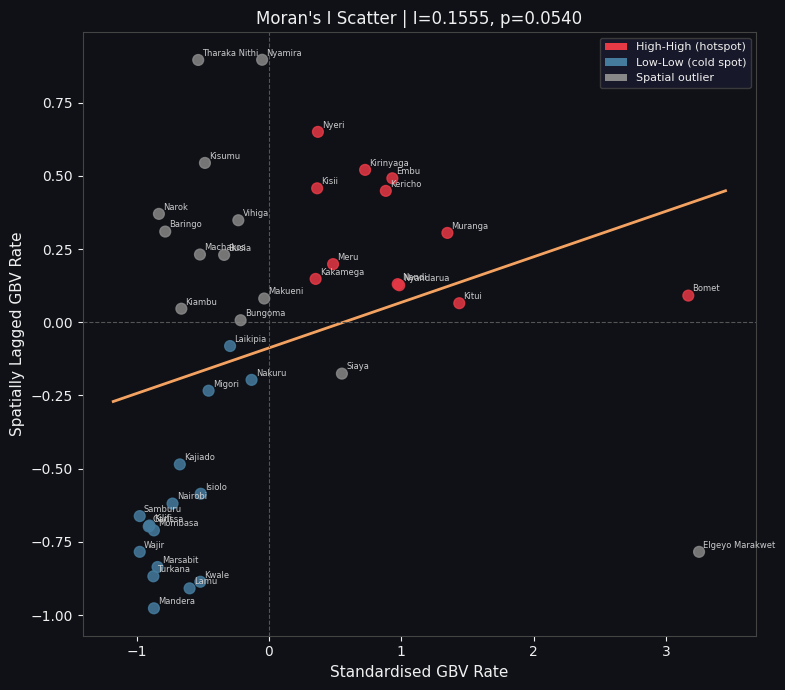

In [8]:
y_std = (y - y.mean()) / y.std()
y_lag = libpysal.weights.lag_spatial(w, y_std)
colors_s = ['#e63946' if yi>0 and li>0 else '#457b9d' if yi<0 and li<0 else '#888'
            for yi,li in zip(y_std,y_lag)]

fig, ax = plt.subplots(figsize=(8,7))
fig.patch.set_facecolor(DARK_BG); ax.set_facecolor(DARK_BG)
ax.scatter(y_std, y_lag, c=colors_s, alpha=0.85, s=60, zorder=3)
m,b = np.polyfit(y_std, y_lag, 1)
xline = np.linspace(y_std.min()-0.2, y_std.max()+0.2, 100)
ax.plot(xline, m*xline+b, color='#f4a261', linewidth=2, label=f"I = {moran.I:.3f}")
ax.axhline(0,color='#555',linewidth=0.8,linestyle='--')
ax.axvline(0,color='#555',linewidth=0.8,linestyle='--')
for i, row in gdf.reset_index(drop=True).iterrows():
    ax.annotate(row['county'],(y_std[i],y_lag[i]),fontsize=6,color='#ccc',xytext=(3,3),textcoords='offset points')
els = [mpatches.Patch(facecolor='#e63946',label='High-High (hotspot)'),
       mpatches.Patch(facecolor='#457b9d',label='Low-Low (cold spot)'),
       mpatches.Patch(facecolor='#888',label='Spatial outlier')]
ax.legend(handles=els,facecolor='#1a1a2e',edgecolor='#444',labelcolor=TEXT_CLR,fontsize=8)
ax.set_xlabel('Standardised GBV Rate',color=TEXT_CLR,fontsize=11)
ax.set_ylabel('Spatially Lagged GBV Rate',color=TEXT_CLR,fontsize=11)
ax.tick_params(colors=TEXT_CLR)
for sp in ax.spines.values(): sp.set_edgecolor('#444')
ax.set_title(f"Moran's I Scatter | I={moran.I:.4f}, p={moran.p_sim:.4f}",color=TEXT_CLR,fontsize=12)
plt.tight_layout()
plt.savefig('outputs/02_moran_scatter.png',dpi=150,bbox_inches='tight',facecolor=DARK_BG)
plt.show()

## LISA cluster map + Getis-Ord Gi*

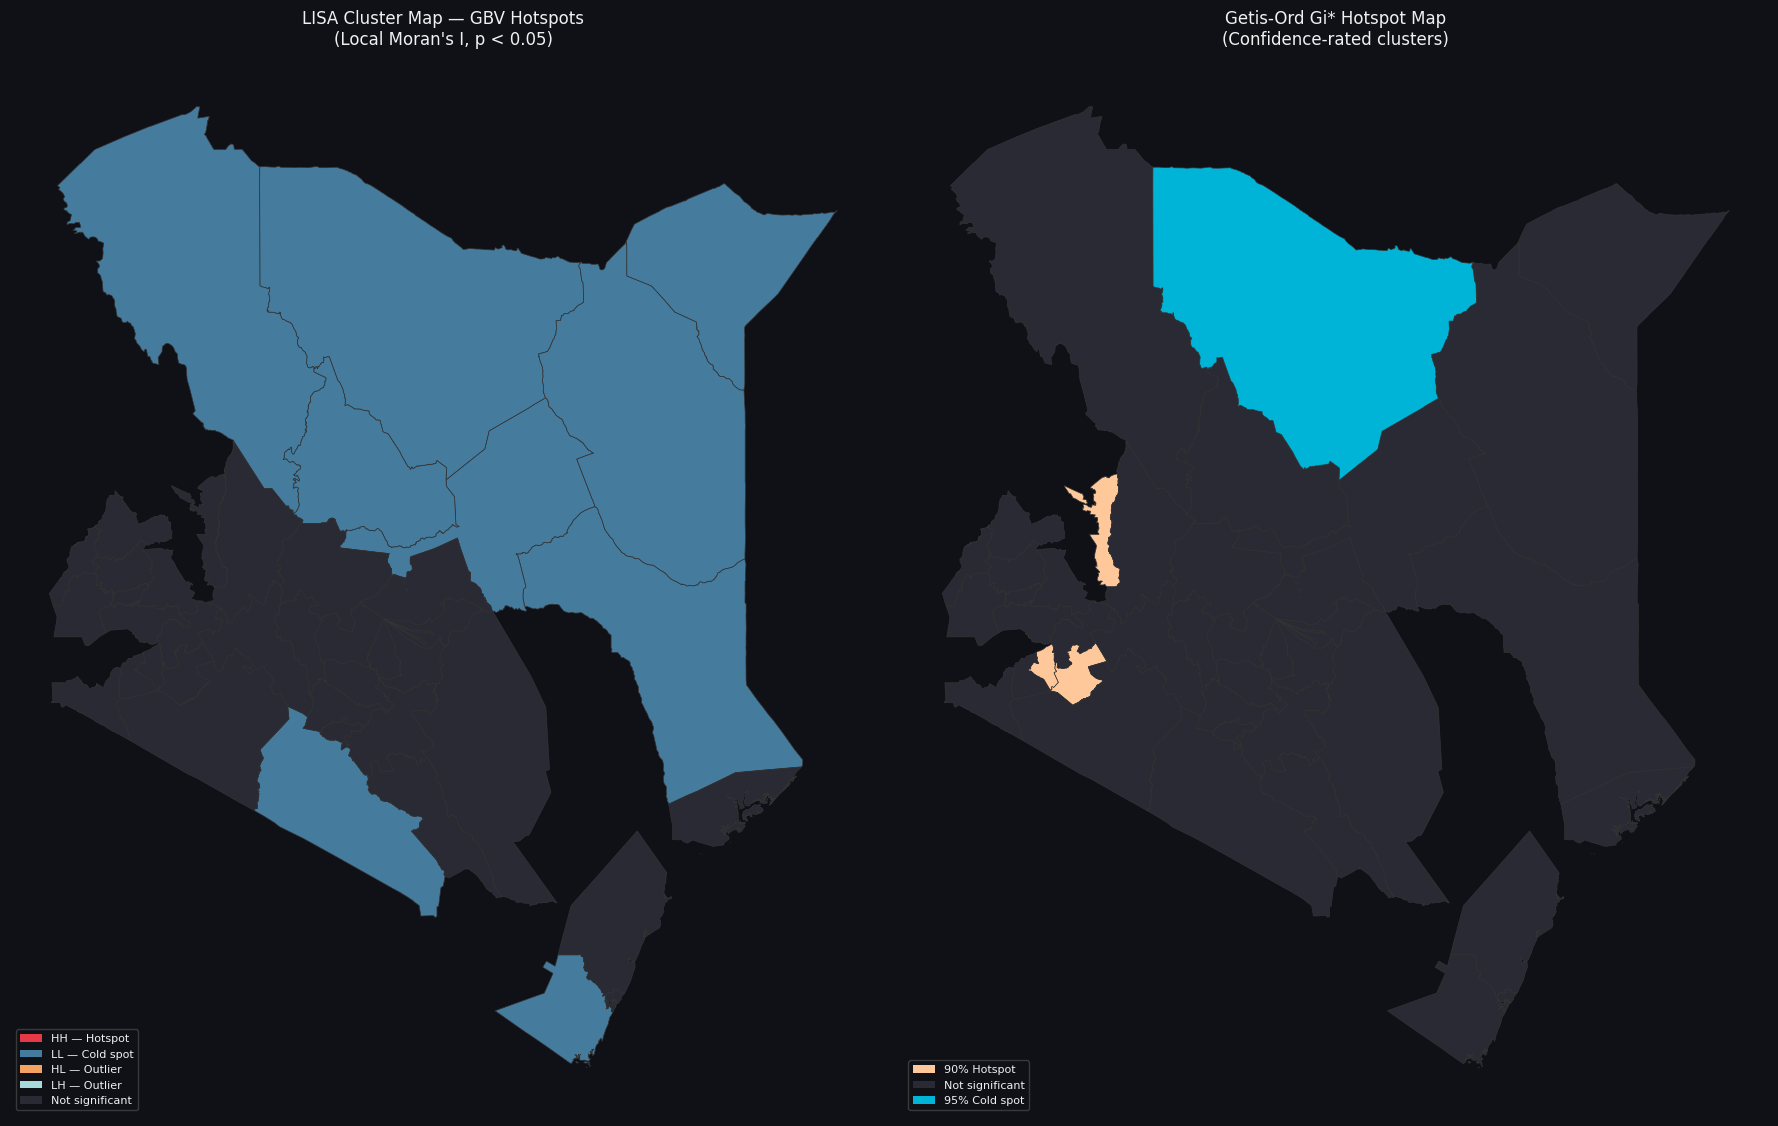

✅ Hotspot counties (LISA HH): []
✅ Hotspot counties (Gi*)    : ['Bomet', 'Elgeyo Marakwet', 'Nyamira']


In [9]:
# LISA
local_moran = Moran_Local(y, w, permutations=999, seed=42)
sig = local_moran.p_sim < 0.05
quad_labels = {1:'HH — Hotspot',2:'LH — Outlier',3:'LL — Cold spot',4:'HL — Outlier'}
gdf['lisa_label'] = [quad_labels[q] if s else 'Not significant' for q,s in zip(local_moran.q, sig)]

# Getis-Ord Gi*
w_b = Queen.from_dataframe(gdf, silence_warnings=True); w_b.transform = 'b'
n = len(y); ym = y.mean(); ys = y.std()
gi_scores = []
for i in range(n):
    nbrs = list(w_b.neighbors[i]) + [i]
    ws = len(nbrs); swy = sum(y[j] for j in nbrs)
    num = swy - ym*ws
    den = ys * np.sqrt((n*ws - ws**2)/(n-1))
    gi_scores.append(num/den if den!=0 else 0)
gdf['gi_star_z'] = gi_scores
def classify_gi(z):
    if z>2.576: return '99% Hotspot'
    if z>1.960: return '95% Hotspot'
    if z>1.645: return '90% Hotspot'
    if z<-2.576: return '99% Cold spot'
    if z<-1.960: return '95% Cold spot'
    return 'Not significant'
gdf['gi_class'] = gdf['gi_star_z'].apply(classify_gi)

# Plot side by side
fig, axes = plt.subplots(1,2,figsize=(18,11))
fig.patch.set_facecolor(DARK_BG)
for ax in axes: ax.set_facecolor(DARK_BG); ax.set_axis_off()

lisa_colors = {'HH — Hotspot':'#e63946','LL — Cold spot':'#457b9d',
               'HL — Outlier':'#f4a261','LH — Outlier':'#a8dadc','Not significant':'#2a2a35'}
for label,color in lisa_colors.items():
    s = gdf[gdf['lisa_label']==label]
    if len(s)>0: s.plot(ax=axes[0],color=color,edgecolor='#333',linewidth=0.5)
axes[0].legend(handles=[mpatches.Patch(facecolor=c,label=l) for l,c in lisa_colors.items()],
    loc='lower left',facecolor=DARK_BG,edgecolor='#444',labelcolor=TEXT_CLR,fontsize=8)
axes[0].set_title("LISA Cluster Map — GBV Hotspots\n(Local Moran's I, p < 0.05)",color=TEXT_CLR,fontsize=12,pad=10)

gi_colors = {'99% Hotspot':'#d62828','95% Hotspot':'#f07167','90% Hotspot':'#fec89a',
             'Not significant':'#2a2a35','95% Cold spot':'#00b4d8','99% Cold spot':'#0077b6'}
for label,color in gi_colors.items():
    s = gdf[gdf['gi_class']==label]
    if len(s)>0: s.plot(ax=axes[1],color=color,edgecolor='#333',linewidth=0.5)
axes[1].legend(handles=[mpatches.Patch(facecolor=c,label=l) for l,c in gi_colors.items() if l in gdf['gi_class'].values],
    loc='lower left',facecolor=DARK_BG,edgecolor='#444',labelcolor=TEXT_CLR,fontsize=8)
axes[1].set_title('Getis-Ord Gi* Hotspot Map\n(Confidence-rated clusters)',color=TEXT_CLR,fontsize=12,pad=10)

plt.tight_layout()
plt.savefig('outputs/03_lisa_gi_star.png',dpi=150,bbox_inches='tight',facecolor=DARK_BG)
plt.show()
print('✅ Hotspot counties (LISA HH):', gdf[gdf['lisa_label']=='HH — Hotspot']['county'].tolist())
print('✅ Hotspot counties (Gi*)    :', gdf[gdf['gi_class'].str.contains('Hotspot',na=False)]['county'].tolist())

---
# 🤖 PHASE 3 : KNN vs Random Forest Model Comparison

## Prepare features for modelling

In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

# Add spatial lag feature
gdf['spatial_lag'] = libpysal.weights.lag_spatial(w, gdf['gbv_rate_per_100k'].values)

# Binary target: above median rate = high risk (1), below = low risk (0)
median_rate = gdf['gbv_rate_per_100k'].median()
gdf['high_risk'] = (gdf['gbv_rate_per_100k'] > median_rate).astype(int)

FEATURES = ['population', 'spatial_lag', 'gi_star_z']
df_model = gdf[FEATURES + ['high_risk','county']].dropna()
X = df_model[FEATURES].values
y_ml = df_model['high_risk'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'✅ Model dataset ready: {len(df_model)} counties')
print(f'   High-risk counties (above median {median_rate:.1f}/100k): {y_ml.sum()}')
print(f'   Low-risk counties: {(y_ml==0).sum()}')
print(f'   Features: {FEATURES}')

✅ Model dataset ready: 41 counties
   High-risk counties (above median 4.4/100k): 20
   Low-risk counties: 21
   Features: ['population', 'spatial_lag', 'gi_star_z']


## KNN model 

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Find best K
print('Finding best K for KNN...')
k_scores = {}
for k in range(3, 12, 2):
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_scaled, y_ml, cv=cv, scoring='f1')
    k_scores[k] = scores.mean()
    print(f'  K={k}: F1 = {scores.mean():.3f} ± {scores.std():.3f}')

best_k = max(k_scores, key=k_scores.get)
print(f'\n  Best K = {best_k} (F1 = {k_scores[best_k]:.3f})')

knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_scaled, y_ml)
knn_cv_scores = cross_val_score(knn_best, X_scaled, y_ml, cv=cv, scoring='f1')
knn_preds = cross_val_predict(knn_best, X_scaled, y_ml, cv=cv)

print(f'\n════════════════════════════')
print(f'  KNN RESULTS (K={best_k})')
print(f'════════════════════════════')
print(f'  CV F1: {knn_cv_scores.mean():.3f} ± {knn_cv_scores.std():.3f}')
print()
print(classification_report(y_ml, knn_preds, target_names=['Low risk','High risk']))

Finding best K for KNN...
  K=3: F1 = 0.841 ± 0.035
  K=5: F1 = 0.847 ± 0.040
  K=7: F1 = 0.829 ± 0.037
  K=9: F1 = 0.829 ± 0.037
  K=11: F1 = 0.829 ± 0.037

  Best K = 5 (F1 = 0.847)

════════════════════════════
  KNN RESULTS (K=5)
════════════════════════════
  CV F1: 0.847 ± 0.040

              precision    recall  f1-score   support

    Low risk       0.94      0.71      0.81        21
   High risk       0.76      0.95      0.84        20

    accuracy                           0.83        41
   macro avg       0.85      0.83      0.83        41
weighted avg       0.85      0.83      0.83        41



## Random Forest model

In [12]:
rf = RandomForestClassifier(n_estimators=200, max_depth=4,
                             min_samples_split=3, class_weight='balanced', random_state=42)
rf.fit(X_scaled, y_ml)
rf_cv_scores = cross_val_score(rf, X_scaled, y_ml, cv=cv, scoring='f1')
rf_preds = cross_val_predict(rf, X_scaled, y_ml, cv=cv)

gdf.loc[df_model.index, 'rf_risk_prob'] = rf.predict_proba(X_scaled)[:, 1]
gdf.loc[df_model.index, 'knn_risk_pred'] = knn_best.predict(X_scaled)
gdf['rf_risk_prob'] = gdf['rf_risk_prob'].fillna(0)

print(f'════════════════════════════')
print(f'  RANDOM FOREST RESULTS')
print(f'════════════════════════════')
print(f'  CV F1: {rf_cv_scores.mean():.3f} ± {rf_cv_scores.std():.3f}')
print()
print(classification_report(y_ml, rf_preds, target_names=['Low risk','High risk']))

════════════════════════════
  RANDOM FOREST RESULTS
════════════════════════════
  CV F1: 0.819 ± 0.049

              precision    recall  f1-score   support

    Low risk       0.88      0.71      0.79        21
   High risk       0.75      0.90      0.82        20

    accuracy                           0.80        41
   macro avg       0.82      0.81      0.80        41
weighted avg       0.82      0.80      0.80        41



## Model comparison 

════════════════════════════════════════
  MODEL COMPARISON SUMMARY
════════════════════════════════════════
               Accuracy  Precision  Recall  F1 Score
KNN (K=5)         0.829       0.76    0.95     0.844
Random Forest     0.805       0.75    0.90     0.818

  Winner: KNN (K=5)


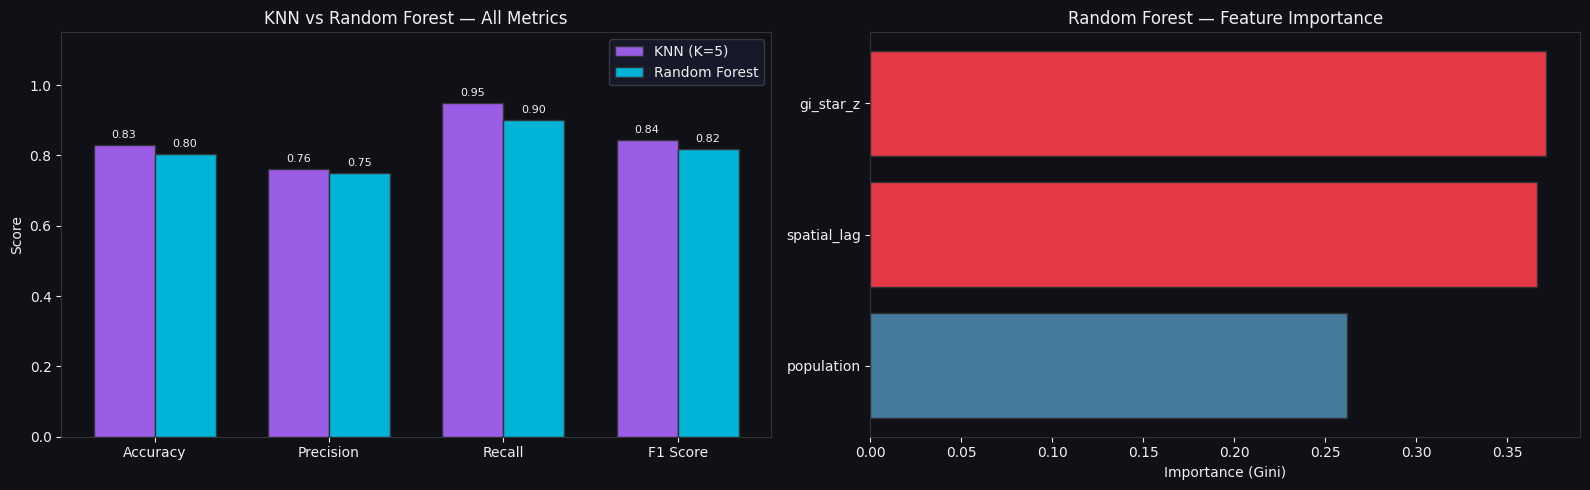


📝 Thesis sentence:
"Comparing KNN (K=5) and Random Forest classifiers, KNN (K=5) achieved
superior performance with a cross-validated F1 score of 0.847
vs 0.819, indicating stronger hotspot prediction capability."


In [13]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

metrics = {
    'Accuracy':  [accuracy_score(y_ml, knn_preds),  accuracy_score(y_ml, rf_preds)],
    'Precision': [precision_score(y_ml, knn_preds, zero_division=0), precision_score(y_ml, rf_preds, zero_division=0)],
    'Recall':    [recall_score(y_ml, knn_preds, zero_division=0),    recall_score(y_ml, rf_preds, zero_division=0)],
    'F1 Score':  [f1_score(y_ml, knn_preds, zero_division=0),        f1_score(y_ml, rf_preds, zero_division=0)],
}
df_compare = pd.DataFrame(metrics, index=[f'KNN (K={best_k})','Random Forest'])

print('════════════════════════════════════════')
print('  MODEL COMPARISON SUMMARY')
print('════════════════════════════════════════')
print(df_compare.round(3).to_string())
winner = 'Random Forest' if rf_cv_scores.mean() > knn_cv_scores.mean() else f'KNN (K={best_k})'
print(f'\n  Winner: {winner}')

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor(DARK_BG)

x = np.arange(len(metrics))
w_bar = 0.35
for ax in axes: ax.set_facecolor(DARK_BG)

axes[0].bar(x - w_bar/2, df_compare.iloc[0], w_bar, label=f'KNN (K={best_k})', color='#9b5de5', edgecolor='#333')
axes[0].bar(x + w_bar/2, df_compare.iloc[1], w_bar, label='Random Forest',      color='#00b4d8', edgecolor='#333')
axes[0].set_xticks(x); axes[0].set_xticklabels(list(metrics.keys()), color=TEXT_CLR)
axes[0].set_ylim(0, 1.15); axes[0].set_ylabel('Score', color=TEXT_CLR)
axes[0].set_title('KNN vs Random Forest — All Metrics', color=TEXT_CLR, fontsize=12)
axes[0].legend(facecolor='#1a1a2e', edgecolor='#444', labelcolor=TEXT_CLR)
axes[0].tick_params(colors=TEXT_CLR)
for sp in axes[0].spines.values(): sp.set_edgecolor('#333')
for i,v in enumerate(df_compare.iloc[0]): axes[0].text(i-w_bar/2, v+0.02, f'{v:.2f}', ha='center', fontsize=8, color=TEXT_CLR)
for i,v in enumerate(df_compare.iloc[1]): axes[0].text(i+w_bar/2, v+0.02, f'{v:.2f}', ha='center', fontsize=8, color=TEXT_CLR)

# Feature importance (RF only)
imp = rf.feature_importances_
idx = np.argsort(imp)[::-1]
fi_colors = ['#e63946' if imp[i]>np.mean(imp) else '#457b9d' for i in idx]
axes[1].barh([FEATURES[i] for i in idx], imp[idx], color=fi_colors, edgecolor='#333')
axes[1].set_xlabel('Importance (Gini)', color=TEXT_CLR)
axes[1].set_title('Random Forest — Feature Importance', color=TEXT_CLR, fontsize=12)
axes[1].tick_params(colors=TEXT_CLR)
axes[1].invert_yaxis()
for sp in axes[1].spines.values(): sp.set_edgecolor('#333')

plt.tight_layout()
plt.savefig('outputs/04_model_comparison.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print('\n📝 Thesis sentence:')
print(f'"Comparing KNN (K={best_k}) and Random Forest classifiers, {winner} achieved')
print(f'superior performance with a cross-validated F1 score of {max(rf_cv_scores.mean(), knn_cv_scores.mean()):.3f}')
print(f'vs {min(rf_cv_scores.mean(), knn_cv_scores.mean()):.3f}, indicating stronger hotspot prediction capability."')

---
# 📅 PHASE 4 :Temporal Analysis (How Hotspots Shifted 2016–2023)


## Incidents per county per year (heatmap)

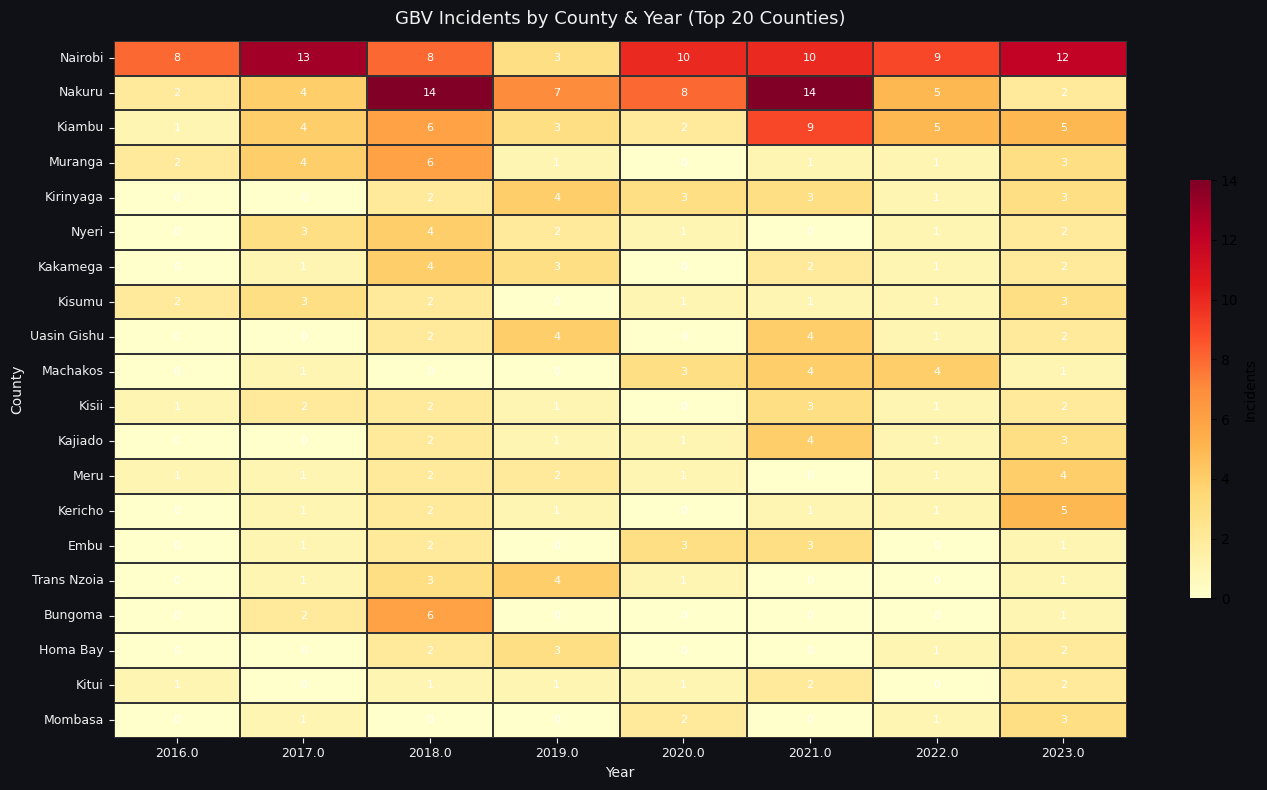

✅ Key insight: which counties got worse over time?


In [14]:
import seaborn as sns

# Count incidents by county and year
yearly = (df_fem.dropna(subset=['county','year'])
          .groupby(['county','year']).size().reset_index(name='incidents'))
pivot = yearly.pivot(index='county', columns='year', values='incidents').fillna(0)

# Keep only top 20 counties by total
top20 = df_agg.nlargest(20, 'total_incidents')['county'].tolist()
pivot_top = pivot.loc[pivot.index.isin(top20)].copy()
pivot_top = pivot_top.loc[pivot_top.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor(DARK_BG)
sns.heatmap(pivot_top, cmap='YlOrRd', linewidths=0.3, linecolor='#333',
            annot=True, fmt='.0f', annot_kws={'size':8,'color':'white'},
            cbar_kws={'label':'Incidents','shrink':0.6}, ax=ax)
ax.set_facecolor(DARK_BG)
ax.set_title('GBV Incidents by County & Year (Top 20 Counties)', color=TEXT_CLR, fontsize=13, pad=12)
ax.set_xlabel('Year', color=TEXT_CLR); ax.set_ylabel('County', color=TEXT_CLR)
ax.tick_params(colors=TEXT_CLR, labelsize=9)
plt.tight_layout()
plt.savefig('outputs/05_temporal_heatmap.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print('✅ Key insight: which counties got worse over time?')

## How hotspots shifted year by year

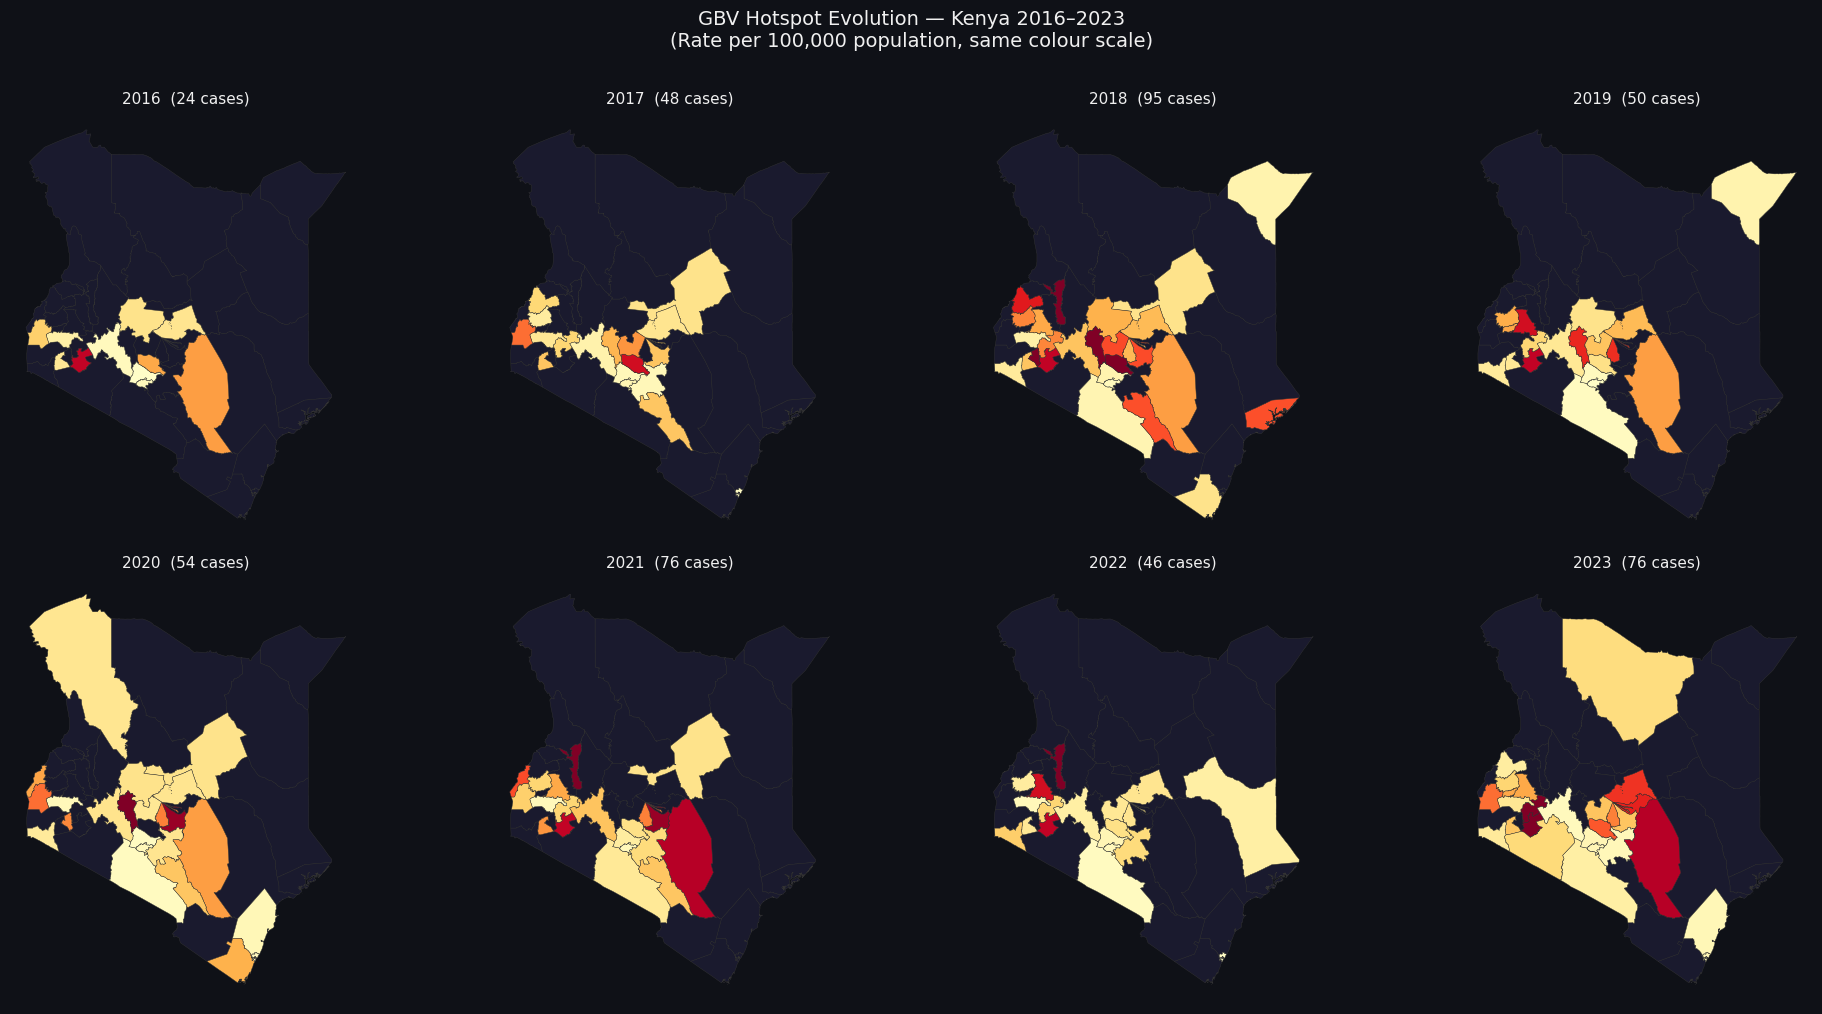

✅ Saved → outputs/06_temporal_maps_grid.png
   This is findings for hotspot evolution over 8 years!


In [16]:
years = sorted(df_fem['year'].dropna().unique().astype(int))
n_years = len(years)
ncols = 4
nrows = (n_years + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 5))
fig.patch.set_facecolor(DARK_BG)
axes_flat = axes.flatten()

# Find global max rate for consistent colour scale
all_rates = []
for yr in years:
    yr_data = df_fem[df_fem['year']==yr].groupby('county').size().reset_index(name='incidents')
    yr_merged = df_pop.merge(yr_data, on='county', how='left')
    yr_merged['incidents'] = yr_merged['incidents'].fillna(0)
    yr_merged['rate'] = (yr_merged['incidents'] / yr_merged['population'] * 100_000).fillna(0)
    all_rates.extend(yr_merged['rate'].tolist())
vmax = np.percentile([r for r in all_rates if r > 0], 95) if any(r > 0 for r in all_rates) else 1

for i, yr in enumerate(years):
    ax = axes_flat[i]
    ax.set_facecolor(DARK_BG); ax.set_axis_off()

    yr_data = df_fem[df_fem['year']==yr].groupby('county').size().reset_index(name='incidents')
    yr_merged = df_pop.merge(yr_data, on='county', how='left')
    yr_merged['incidents'] = yr_merged['incidents'].fillna(0)
    yr_merged['rate'] = (yr_merged['incidents'] / yr_merged['population'] * 100_000).fillna(0)
    yr_gdf = gdf_shape.merge(yr_merged[['county','rate']], on='county', how='left').fillna(0)

    yr_gdf[yr_gdf['rate']==0].plot(ax=ax, color='#1a1a2e', edgecolor='#333', linewidth=0.3)
    yr_gdf[yr_gdf['rate']>0].plot(
        column='rate', cmap='YlOrRd', vmin=0, vmax=vmax,
        linewidth=0.3, edgecolor='#333', ax=ax,
        missing_kwds={'color':'#1a1a2e'})

    total = int(df_fem[df_fem['year']==yr].shape[0])
    ax.set_title(f'{int(yr)}  ({total} cases)', color=TEXT_CLR, fontsize=11, pad=6)

# Hide unused subplots
for j in range(i+1, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle('GBV Hotspot Evolution — Kenya 2016–2023\n(Rate per 100,000 population, same colour scale)',
             color=TEXT_CLR, fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('outputs/06_temporal_maps_grid.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print('✅ Saved → outputs/06_temporal_maps_grid.png')
print('   This is findings for hotspot evolution over 8 years!')

## Rising vs declining hotspots (trend lines for top counties)

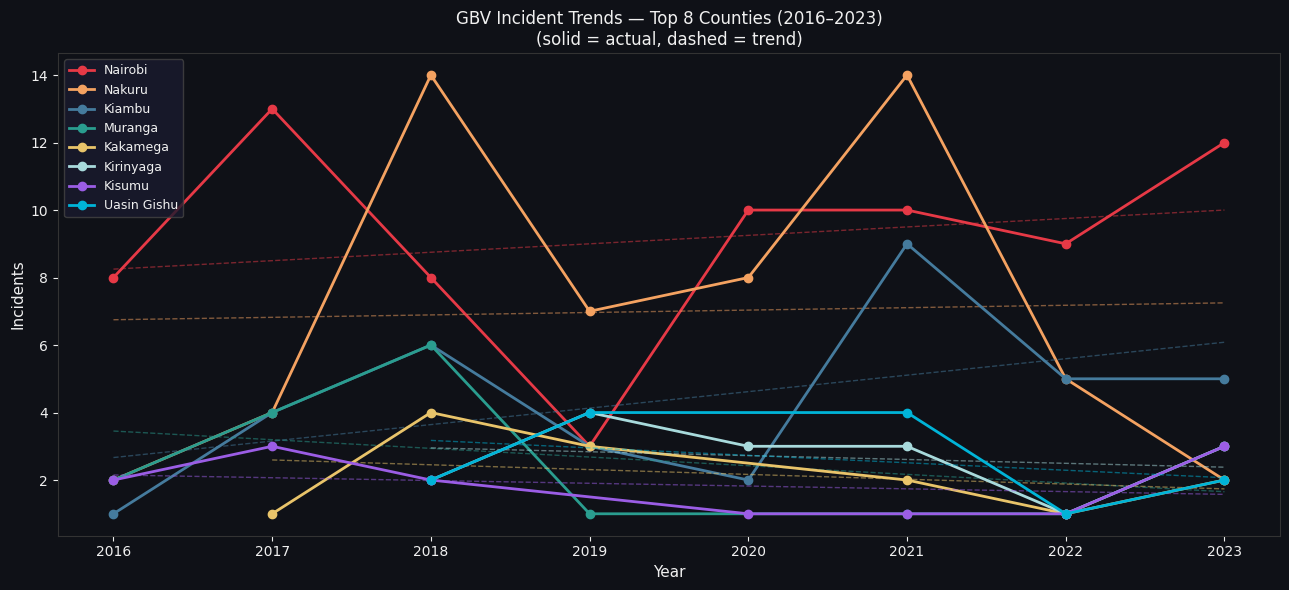

✅ Counties with rising trends need most urgent intervention


In [17]:
# Top 8 counties trend lines
top8 = df_agg.nlargest(8, 'total_incidents')['county'].tolist()
yearly_top = yearly[yearly['county'].isin(top8)]

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor(DARK_BG); ax.set_facecolor(DARK_BG)

palette = ['#e63946','#f4a261','#457b9d','#2a9d8f','#e9c46a','#a8dadc','#9b5de5','#00b4d8']
for county, color in zip(top8, palette):
    data = yearly_top[yearly_top['county']==county].sort_values('year')
    ax.plot(data['year'], data['incidents'], marker='o', color=color,
            linewidth=2, markersize=6, label=county)
    # Trend line
    if len(data) >= 3:
        z = np.polyfit(data['year'], data['incidents'], 1)
        p = np.poly1d(z)
        ax.plot(data['year'], p(data['year']), color=color, linewidth=1,
                linestyle='--', alpha=0.5)

ax.set_xlabel('Year', color=TEXT_CLR, fontsize=11)
ax.set_ylabel('Incidents', color=TEXT_CLR, fontsize=11)
ax.set_title('GBV Incident Trends — Top 8 Counties (2016–2023)\n(solid = actual, dashed = trend)',
             color=TEXT_CLR, fontsize=12)
ax.legend(facecolor='#1a1a2e', edgecolor='#444', labelcolor=TEXT_CLR, fontsize=9, loc='upper left')
ax.tick_params(colors=TEXT_CLR)
ax.set_xticks(years)
for sp in ax.spines.values(): sp.set_edgecolor('#333')
plt.tight_layout()
plt.savefig('outputs/07_county_trend_lines.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print('✅ Counties with rising trends need most urgent intervention')

---
# 🌐 PHASE 5: Interactive Dashboard

## Interactive Folium map (all layers + temporal slider)

In [18]:
import folium
from folium.plugins import HeatMap, MiniMap, Fullscreen
import branca.colormap as cm

gdf_map = gdf.to_crs(epsg=4326) if gdf.crs and gdf.crs.to_epsg() != 4326 else gdf.copy()

m = folium.Map(location=[0.02, 37.9], zoom_start=6, tiles=None)
folium.TileLayer('CartoDB dark_matter', name='Dark basemap').add_to(m)
folium.TileLayer('CartoDB positron',    name='Light basemap').add_to(m)

vals = gdf_map['gbv_rate_per_100k'].replace(0, np.nan).dropna()
colormap = cm.LinearColormap(['#ffffcc','#fd8d3c','#bd0026'],
    vmin=vals.quantile(0.05), vmax=vals.quantile(0.95),
    caption='GBV rate per 100,000 population')

gjson = gdf_map.to_json()

# Layer 1: GBV rate
folium.GeoJson(gjson, name='GBV Rate per 100k',
    style_function=lambda f: {
        'fillColor': colormap(f['properties']['gbv_rate_per_100k']) if (f['properties']['gbv_rate_per_100k'] or 0)>0 else '#1a1a2e',
        'fillOpacity':0.75,'color':'#ffffff','weight':0.5},
    highlight_function=lambda f: {'weight':2,'fillOpacity':0.9},
    tooltip=folium.GeoJsonTooltip(
        fields=['county','gbv_rate_per_100k','total_incidents'],
        aliases=['County:','Rate/100k:','Total incidents:'],
        style='background:#1a1a2e;color:#eee;font-family:sans-serif;font-size:12px;border-radius:6px;'),
    show=True).add_to(m)
colormap.add_to(m)

# Layer 2: Gi* hotspots
gi_col = {'99% Hotspot':'#d62828','95% Hotspot':'#f07167','90% Hotspot':'#fec89a',
          'Not significant':'#1a1a2e66','95% Cold spot':'#00b4d8','99% Cold spot':'#0077b6'}
folium.GeoJson(gjson, name='Getis-Ord Gi* Hotspots',
    style_function=lambda f: {
        'fillColor': gi_col.get(f['properties'].get('gi_class','Not significant'),'#1a1a2e'),
        'fillOpacity':0.75,'color':'#ffffff','weight':0.5},
    tooltip=folium.GeoJsonTooltip(
        fields=['county','gi_star_z','gi_class'],
        aliases=['County:','Gi* z-score:','Classification:'],
        style='background:#1a1a2e;color:#eee;font-family:sans-serif;font-size:12px;border-radius:6px;'),
    show=False).add_to(m)

# Layer 3: RF risk
rf_cm = cm.LinearColormap(['#1a9850','#ffffbf','#d73027'], vmin=0, vmax=1,
    caption='RF predicted risk probability')
folium.GeoJson(gjson, name='RF Predicted Risk',
    style_function=lambda f: {
        'fillColor': rf_cm(f['properties'].get('rf_risk_prob') or 0),
        'fillOpacity':0.75,'color':'#ffffff','weight':0.5},
    tooltip=folium.GeoJsonTooltip(
        fields=['county','rf_risk_prob','lisa_label'],
        aliases=['County:','RF Risk:','LISA:'],
        style='background:#1a1a2e;color:#eee;font-family:sans-serif;font-size:12px;border-radius:6px;'),
    show=False).add_to(m)
rf_cm.add_to(m)

# Layer 4: KDE heatmap
heat_data = [[r.geometry.centroid.y, r.geometry.centroid.x, r['gbv_rate_per_100k']]
             for _,r in gdf_map.iterrows() if r.geometry and r['gbv_rate_per_100k']>0]
HeatMap(heat_data, name='KDE Heatmap', radius=35, blur=25,
    gradient={'0.4':'#ffffcc','0.65':'#fd8d3c','1':'#bd0026'}, show=False).add_to(m)

MiniMap(toggle_display=True, tile_layer='CartoDB dark_matter').add_to(m)
Fullscreen(position='topright').add_to(m)
folium.LayerControl(position='topright', collapsed=False).add_to(m)

m.get_root().html.add_child(folium.Element("""
<div style='position:fixed;top:10px;left:50%;transform:translateX(-50%);z-index:1000;
  background:#1a1a2e;color:#fff;padding:10px 24px;border-radius:8px;
  font-family:sans-serif;font-size:14px;font-weight:600;border:1px solid #444;'>
  GBV Hotspot Prediction — Kenya 2016–2023
  <span style='font-weight:400;font-size:11px;color:#aaa;margin-left:10px'>Final Year Project</span>
</div>"""))

m.save('outputs/gbv_hotspot_dashboard.html')
print('✅ Dashboard saved → outputs/gbv_hotspot_dashboard.html')
print('   Open this file in Chrome or Firefox — no internet needed')

✅ Dashboard saved → outputs/gbv_hotspot_dashboard.html
   Open this file in Chrome or Firefox — no internet needed


## Preview the map

In [19]:
from IPython.display import display
display(m)

## Save outputs

In [24]:
gdf.to_file('outputs/master_gbv_modelled.geojson', driver='GeoJSON')
gdf.drop(columns='geometry').to_csv('outputs/master_gbv_modelled.csv', index=False)
df_compare.round(3).to_csv('outputs/model_comparison.csv')
pivot.to_csv('outputs/incidents_by_county_year.csv')

print()
print('Your outputs/ folder now contains:')
print('  01_initial_maps.png           — county choropleth maps')
print('  01b_descriptive_charts.png    — who commits femicide')
print('  02_moran_scatter.png          — spatial autocorrelation')
print('  03_lisa_gi_star.png           — LISA + Gi* hotspot maps')
print('  04_model_comparison.png       — KNN vs Random Forest')
print('  05_temporal_heatmap.png       — incidents by county & year')
print('  06_temporal_maps_grid.png     — hotspot maps 2016–2023 (ORIGINAL!)')
print('  07_county_trend_lines.png     — rising vs declining counties')
print('  model_comparison.csv          — exact scores for my thesis')
print('  incidents_by_county_year.csv  — temporal data table')
print('  gbv_hotspot_dashboard.html    — interactive map')
print()


Your outputs/ folder now contains:
  01_initial_maps.png           — county choropleth maps
  01b_descriptive_charts.png    — who commits femicide
  02_moran_scatter.png          — spatial autocorrelation
  03_lisa_gi_star.png           — LISA + Gi* hotspot maps
  04_model_comparison.png       — KNN vs Random Forest
  05_temporal_heatmap.png       — incidents by county & year
  06_temporal_maps_grid.png     — hotspot maps 2016–2023 (ORIGINAL!)
  07_county_trend_lines.png     — rising vs declining counties
  model_comparison.csv          — exact scores for my thesis
  incidents_by_county_year.csv  — temporal data table
  gbv_hotspot_dashboard.html    — interactive map



In [25]:
import requests
r = requests.get("https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_KEN_1.json", timeout=60)
with open("kenya_counties.geojson", "wb") as f:
    f.write(r.content)
print("Done! File saved.")

Done! File saved.
